# Piglet Experiment

We are first tasked with reproducing the results from the simplified version of Piglet within the report, which can be found in Figure 2. The modified variant of Piglet involves both players taking turns, racing to a score of two. On each turn, the player flips a coin, if the player flips a head they add one to their turn score, if tails their turn score is reduced to zero and their turn is ended. Given the players turn continues, they may choose whether to flip again or hold, where flipping brings the player closer to victory, but comes with the risk of losing their turn total. We are thus interested in finding the probability of winning from each non-winning state.

We are interested in solving this problem via the value iteration algorithm. We define the probability of winning from your score i, opponent score j and current turn score k as $P_{i,j,k}$. There are thus six possible non-winning states we wish to find the probability of winning from. These are $P_{0,0,0}$, $P_{0,0,1}$, $P_{0,1,0}$, $P_{0,1,1}$, $P_{1,0,0}$ and $P_{1,1,0}$. We will define our algorithm within a function. The function first defines the six states in the form of a list. The dictionaries 'value_func' and 'history' contain the current probability estimates and the history of probability estimates per iteration respectively. We set all the initial probability estimates to zero in line with value iteration theory. The function V returns the current value of each state from our dictionary 'value_func', except in the special case where the player can win by holding, in which it returns one.

For each iteration at each state we work out the probability of winning given you flip and given you hold, then select our new estimate to be the maximum of these two values. The probability of winning if we hold, $P_{i,j,k,\text{Hold}}$, is simply just one minus the probability our opponent wins given our updated score. The probability of winning if we flip, $P_{i,j,k,\text{Flip}}$, has two cases. If we roll a head, it is the probability of winning from our turn score plus one. If tails, it is one minus the probability our opponent wins given we scored nothing. These two possibilities can then be combined into one equation. The formulas for this can be found below:

At each iteration, for each state (i, j, k):
$$
\begin{aligned}
\hat{P}_{i,j,k} &= \begin{cases}\text{Current Estimate for State (i, j, k)} & \text{if $i +k < 2$} \\ 1 & \text{otherwise} \end{cases} \\
\\
P_{i,j,k,\text{Hold}} &= 1 - \hat{P}_{j,i+k,0} \\
\\
P_{i,j,k,\text{Flip}} &= \frac{1}{2} (1-\hat{P}_{j,i,0} + \hat{P}_{i,j,k+1}) \\
\\
\hat{P}_{i,j,k} &= \max{(P_{i,j,k,\text{Hold}},P_{i,j,k,\text{Flip}})} \quad \text{(Update Estimate for State (i, j, k))}
\end{aligned}
$$

This process continues until we have iterated enough for the values to converge. This whole process in contained in the 'piglet_value_iteration' function below:

In [10]:
import matplotlib.pyplot as plt

def piglet_value_iteration(iterations: int = 25):
    """
    Runs value iteration for Piglet with goal = 2

    A state is (i, j, k):
    i = current player's score
    j = opponent's score
    k = current turn total

    Returns the value history for plotting and the final values
    """
    # The six non-winning states for Piglet when the goal is 2
    states = [
        (0, 0, 0),
        (0, 0, 1),
        (0, 1, 0),
        (0, 1, 1),
        (1, 0, 0),
        (1, 1, 0),
    ]

    # Start every win probability estimate at 0.
    value_func = {state: 0 for state in states}
    history = {
        state: [value_func[state]]
        for state in states
    }

    def V(i: int, j: int, k: int) -> float:
        """
        Gets the current value of a state. If the player can already win by holding, return 1
        """
        if i + k >= 2:
            return 1
        return value_func[(i, j, k)]

    # Repeatedly update the value estimates
    for _ in range(iterations):
        for i, j, k in states:
            flip_value = 0.5 * (
                (1.0 - V(j, i, 0)) + V(i, j, k + 1)
            )
            hold_value = 1.0 - V(j, i + k, 0)
            # Selects whether to flip or hold
            value_func[(i, j, k)] = max(flip_value, hold_value)
        # Save values
        for state in states:
            history[state].append(value_func[state])

    return history, value_func


We have now constructed a function that implements the value iteration algorithm, and records the value of the estimate at each iteration. The function below runs our algorithm for twenty five iterations, to replicate the results in the report. It then plots the probability estimates for each iteration and returns the final results.

In [11]:
def plot_piglet_figure():
    history, final_values = piglet_value_iteration(iterations=25)

    labels = {
        (0, 0, 0): "P0,0,0",
        (0, 0, 1): "P0,0,1",
        (0, 1, 0): "P0,1,0",
        (0, 1, 1): "P0,1,1",
        (1, 0, 0): "P1,0,0",
        (1, 1, 0): "P1,1,0",
    }

    plot_order = [
        (1, 0, 0),
        (0, 0, 1),
        (1, 1, 0),
        (0, 1, 1),
        (0, 0, 0),
        (0, 1, 0),
    ]

    plt.figure(figsize=(8, 6))

    for state in plot_order:
        y_values = history[state]
        x_values = range(len(y_values))
        plt.plot(
            x_values,
            y_values,
            color="black",
            linewidth=1
        )
        plt.text(
            len(y_values) - 1 + 0.25,
            y_values[-1],
            labels[state],
            va="center",
            fontsize=9
        )

    plt.xlim(0, 25)
    plt.ylim(0, 1)
    plt.xlabel("Iteration")
    plt.ylabel("Win Probability")
    plt.xticks(range(0, 26, 5))
    plt.yticks([x / 10 for x in range(0, 11)])
    plt.subplots_adjust(right=0.82)
    plt.show()
    print("Final values:")
    for state in plot_order:
        print(f"{labels[state]} = {final_values[state]:.6f}")

By running this function, we obtain a graph showing the estimated value of each probability at each iteration. From this graph we can observe how the estimates converge over the multiple iterations. In addition, we can find the exact final values after twenty five iterations as an output from our function.

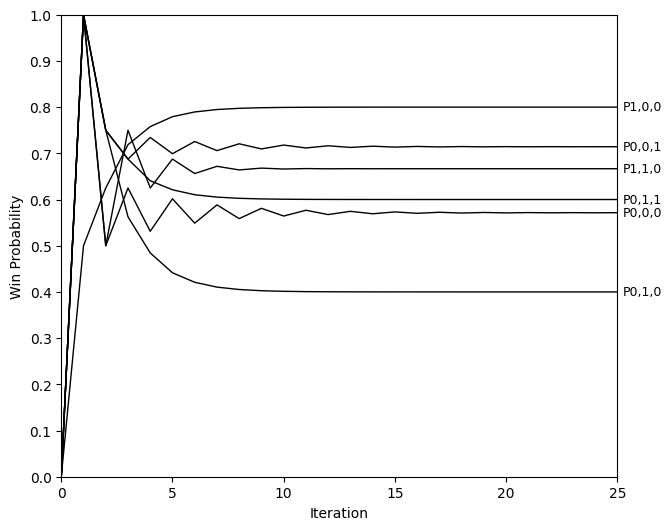

Final values:
P1,0,0 = 0.800000
P0,0,1 = 0.714238
P1,1,0 = 0.666667
P0,1,1 = 0.600000
P0,0,0 = 0.571524
P0,1,0 = 0.400000


In [12]:
plot_piglet_figure()

### Final Results

The final results from our experiment can be found displayed in fraction form in the below table:
| State (i,j,k)  | Probability of Winning |
|:--:|:--:|
| (0,0,0) | $\frac{4}{7}$ |
| (0,0,1)| $\frac{5}{7}$ |
| (0,1,0) | $\frac{2}{5}$ |
| (0,1,1) | $\frac{3}{5}$ |
| (1,0,0) | $\frac{4}{5}$ |
| (1,1,0) | $\frac{2}{3}$ |